<a href="https://colab.research.google.com/github/Sneha8126/Python-Assignment/blob/main/AssignmentRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/House Price Prediction Dataset.csv')

In [ ]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
df['Condition'].value_counts()

,count
Condition,
Fair,521
Excellent,511
Poor,507
Good,461


In [ ]:
condition_map = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
}

In [ ]:
df['Condition'] = df['Condition'].replace(condition_map)

/tmp/ipykernel_666/1207046610.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Condition'] = df['Condition'].replace(condition_map)


In [ ]:
df['Condition'].value_counts()

,count
Condition,
1,521
3,511
0,507
2,461


In [ ]:

df['Garage'] = df['Garage'].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_666/2206010563.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Garage'] = df['Garage'].replace({'Yes': 1, 'No': 0})


In [ ]:
df['Garage'].value_counts()

,count
Garage,
0,1038
1,962


In [ ]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,3,0,149919
1,2,4272,5,4,3,1958,Downtown,3,0,424998
2,3,3592,2,2,3,1938,Downtown,2,0,266746
3,4,966,4,2,2,1902,Suburban,1,1,244020
4,5,4926,1,4,2,1975,Downtown,1,1,636056


In [ ]:
df = pd.get_dummies(df, columns=['Location'], drop_first=True)

In [ ]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition,Garage,Price,Location_Rural,Location_Suburban,Location_Urban
0,1,1360,5,4,3,1970,3,0,149919,False,False,False
1,2,4272,5,4,3,1958,3,0,424998,False,False,False
2,3,3592,2,2,3,1938,2,0,266746,False,False,False
3,4,966,4,2,2,1902,1,1,244020,False,True,False
4,5,4926,1,4,2,1975,1,1,636056,False,False,False


Step 2:- Pre-process your
data

In [ ]:
int_columns = df.describe().columns
int_columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Condition', 'Garage', 'Price'],
      dtype='object')

In [ ]:
int_df = df[int_columns]
int_df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition,Garage,Price
0,1,1360,5,4,3,1970,3,0,149919
1,2,4272,5,4,3,1958,3,0,424998
2,3,3592,2,2,3,1938,2,0,266746
3,4,966,4,2,2,1902,1,1,244020
4,5,4926,1,4,2,1975,1,1,636056


In [ ]:
import seaborn as sns

<Axes: >

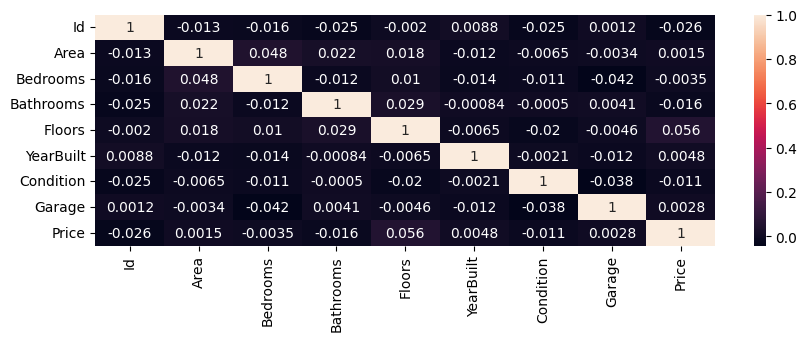

In [ ]:
plt.figure(figsize=(10,3))
sns.heatmap(int_df.corr(),annot=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 2000 non-null   int64
 1   Area               2000 non-null   int64
 2   Bedrooms           2000 non-null   int64
 3   Bathrooms          2000 non-null   int64
 4   Floors             2000 non-null   int64
 5   YearBuilt          2000 non-null   int64
 6   Condition          2000 non-null   int64
 7   Garage             2000 non-null   int64
 8   Price              2000 non-null   int64
 9   Location_Rural     2000 non-null   bool 
 10  Location_Suburban  2000 non-null   bool 
 11  Location_Urban     2000 non-null   bool 
dtypes: bool(3), int64(9)
memory usage: 146.6 KB


Step 3:- Split data into
train &validation
sets
data

In [ ]:
x = df.drop('Price', axis=1)
y = df['Price']

In [ ]:
x.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Condition,Garage,Location_Rural,Location_Suburban,Location_Urban
0,1,1360,5,4,3,1970,3,0,False,False,False
1,2,4272,5,4,3,1958,3,0,False,False,False
2,3,3592,2,2,3,1938,2,0,False,False,False
3,4,966,4,2,2,1902,1,1,False,True,False
4,5,4926,1,4,2,1975,1,1,False,False,False


In [ ]:
y.head()

,Price
0,149919
1,424998
2,266746
3,244020
4,636056


In [ ]:
x.shape

(2000, 11)

In [ ]:

from sklearn.model_selection import train_test_split


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(1600, 11)

In [ ]:
x_test.shape

(400, 11)

Step 4:- Train your model

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
model.coef_

array([-1.21047338e+01, -2.31880995e-01,  1.29780565e+02, -1.01904679e+04,
        2.36303767e+04,  1.05341549e+02, -4.95077398e+03,  2.50772737e+03,
        2.77927580e+03,  1.21003990e+04, -1.30513480e+04])

In [ ]:
train_pred = model.predict(x_train)
train_pred[:5]

array([519959.2794904 , 514264.48373416, 488861.13278326, 523692.51561303,
       502744.66605748])

In [ ]:
y_train.head().values

array([434325, 614772, 922811, 794314, 796988])

In [ ]:
test_pred = model.predict(x_test)
test_pred[:5]

array([492565.49866754, 540631.38387024, 477506.37929927, 555323.65645566,
       563965.03974872])

In [ ]:
y_test.head().values

array([514764, 694256,  66375, 650243, 223285])

Step 5:- Evaluate the
model

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
print('Train Mean Squared Error :-',mean_squared_error(y_train,train_pred))
print('Train Root Mean Squared Error :-',np.sqrt(mean_squared_error(y_train,train_pred)))
print('Train Mean Absolute Error :-',mean_absolute_error(y_train,train_pred))
print('Train Mean Absolute Percentage Error :-',mean_absolute_percentage_error(y_train,train_pred))
print('Train R2 Score :-',r2_score(y_train,train_pred))

Train Mean Squared Error :- 75356086404.36562
Train Root Mean Squared Error :- 274510.6307674907
Train Mean Absolute Error :- 237267.69348895634
Train Mean Absolute Percentage Error :- 0.9299482790750543
Train R2 Score :- 0.00857065545486646


In [ ]:
print('Test Mean Squared Error :-',mean_absolute_error(y_test,test_pred))
print('Test Root Mean Squared Error :-',np.sqrt(mean_squared_error(y_test,test_pred)))
print('Test Mean Absolute Error :-',mean_absolute_error(y_test,test_pred))
print('Test Mean Absolute Percentage Error :-',mean_absolute_percentage_error(y_test,test_pred))
print('Test R2 Score :-',r2_score(y_test,test_pred))

Test Mean Squared Error :- 243076.62633879678
Test Root Mean Squared Error :- 279977.7136307904
Test Mean Absolute Error :- 243076.62633879678
Test Mean Absolute Percentage Error :- 1.0362583946464425
Test R2 Score :- -0.007566844144381246
